# Bayesian Optimization Demo
## Gaussian Processes with Different Acquisition Functions

This notebook demonstrates:
1. Implementing Gaussian Processes (GPs) using scikit-learn
2. Creating modular acquisition functions
3. Full Bayesian Optimization loop visualization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

np.random.seed(42)

## 1. Objective Function
We'll optimize a synthetic function (unknown in real scenarios):

$f(x) = sin(3x)  x^2 - 0.7x \quad \forall x \in [-3,3]$

**Key Properties**:
- Non-convex
- Multiple local maxima
- Expensive to evaluate (in real applications)


In [2]:
def f(x, noise = 0):
    return -np.sin(3*x) - x**2 + 0.7*x + noise * np.random.randn(*x.shape)

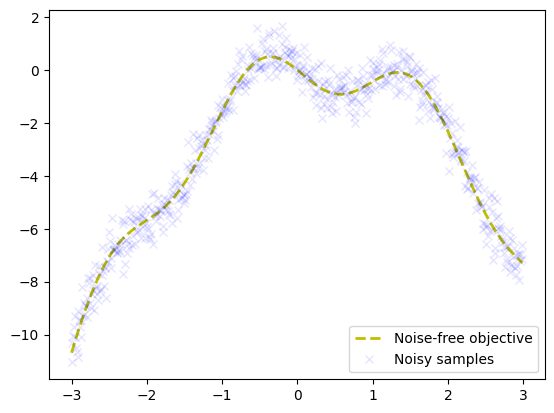

In [3]:
import matplotlib.pyplot as plt

bounds = np.array([-3.0, 3.0])

# Dense grid of points within bounds
X = np.arange(bounds[0], bounds[1], 0.01).reshape(-1, 1)

# Noise-free objective function values at X
Y = f(X)

# Plot optimization objective with noise level
plt.plot(X, Y, 'y--', lw=2, label='Noise-free objective')
plt.plot(X, f(X, 0.5), 'bx', lw=1, alpha=0.1, label='Noisy samples')
plt.legend();

## 2. Gaussian Process Setup
### Initialization with random points






In [6]:
X = np.arange(bounds[0], bounds[1], 0.01).reshape(-1, 1)
y = f(X, noise = 0)
training_indices = np.random.choice(np.arange(y.size), size=8, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

print(f"Number of points in the prior are {X_train.shape[0]}")

Number of points in the prior are 8


We use a composite kernel:
```python
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))
```

**Why This Works**:
- `ConstantKernel` models signal variance
- `RBF` (Squared Exponential) kernel captures smoothness
- `normalize_y=True` helps with numerical stability

Can you train a GP on this function?

In [8]:
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
gp.fit(X_train, y_train)
mean_prediction, std_prediction = gp.predict(X, return_std=True)

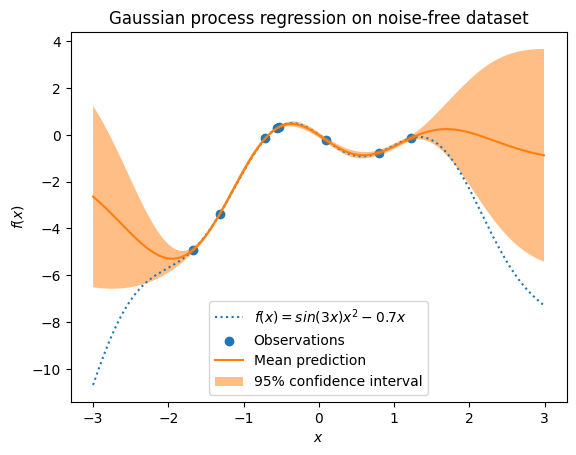

In [9]:

plt.plot(X, y, label=r"$f(x) = sin(3x)  x^2 - 0.7x$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

## 3. Acquisition Functions Framework
Our modular implementation allows easy swapping:

In [104]:
class AcquisitionFunctions:
    @staticmethod
    def ei(x, gp, y_best, xi=0.01):
        mu, sigma = gp.predict(x, return_std=True)
        z = (mu - y_best - xi) / sigma
        return (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)

    @staticmethod
    def ucb(x, gp, kappa=2.0):
        mu, sigma = gp.predict(x, return_std=True)
        return mu + kappa * sigma

    @staticmethod
    def pi(x, gp, y_best, xi=0.01):
        # TODO: Implement Probability of Improvement
        raise NotImplementedError("PI not implemented - student exercise")


In [113]:
def bayesian_optimization(func, X_history, y_history, bounds, n_iter=5, acq_func='ei'):


    for i in range(n_iter):
        # Fit GP
        gp.fit(X_history, y_history)

        # Generate test points
        x_test = np.linspace(bounds[0], bounds[1], 10000).reshape(-1, 1)

        # Select acquisition function
        y_best = np.max(y_history)
        if acq_func == 'ei':
            acq = AcquisitionFunctions.ei(x_test, gp, y_best)
        elif acq_func == 'ucb':
            acq = AcquisitionFunctions.ucb(x_test, gp)
        else:
            raise ValueError("Unknown acquisition function")

        # Select next point
        next_x = x_test[np.argmax(acq)]

        # Evaluate objective (simulated)
        next_y = func(next_x)
        plot_state(func, gp, X_history, y_history, x_test, acq, next_x, i+1, n_iter)

        # Update data
        X_history = np.vstack((X_history, next_x))
        y_history = np.append(y_history, next_y)

        print(f"End of Iteration {i}: Point _sampled is {next_x} and value is {next_y}")

    return X_history, y_history

In [114]:
def plot_state(func, gp, X_current, y_current, x_test, acq, next_x, iteration, n_iter):
    mu, sigma = gp.predict(x_test, return_std=True)

    fig, (ax1, ax2) = plt.subplots(2,1, figsize = (5,5))

    # Function subplot
    ax1.plot(x_test, func(x_test), 'r--', label='True function')
    ax1.plot(x_test, mu, 'b-', label='GP mean')
    ax1.fill_between(x_test.ravel(), mu - sigma, mu + sigma, alpha=0.2)
    ax1.plot(X_current, y_current, 'ro', markersize=10, label='Observations')
    ax1.plot(next_x, objective_function(next_x), 'g*', markersize=15,
             label='Proposed point', zorder=10)
    ax1.set_title(f"Iteration {iteration}: GP Posterior and True Function")
    ax1.set_ylabel("Objective Value")
    ax1.legend(loc='upper left')

    # Acquisition subplot
    ax2.plot(x_test, acq, 'm-', label='Acquisition function')
    ax2.plot(next_x, np.max(acq), 'g*', markersize=15,
             label='Maximum acquisition', zorder=10)
    ax2.set_title("Acquisition Function Landscape")
    ax2.set_xlabel("x")
    ax2.set_ylabel("Acquisition Value")
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

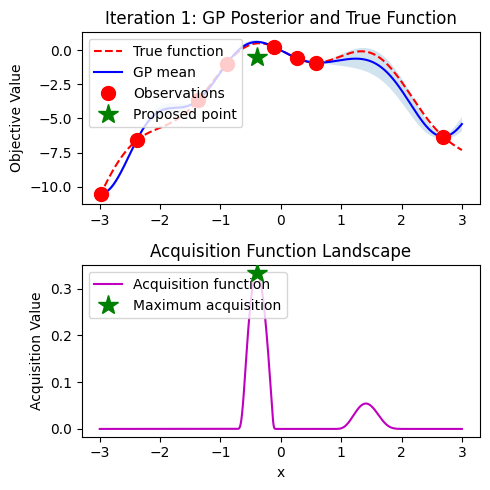

End of Iteration 0: Point _sampled is [-0.39693969] and value is [0.49325417]


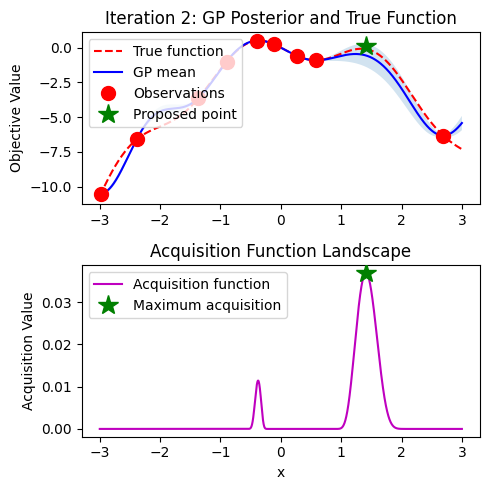

End of Iteration 1: Point _sampled is [1.40984098] and value is [-0.1150951]


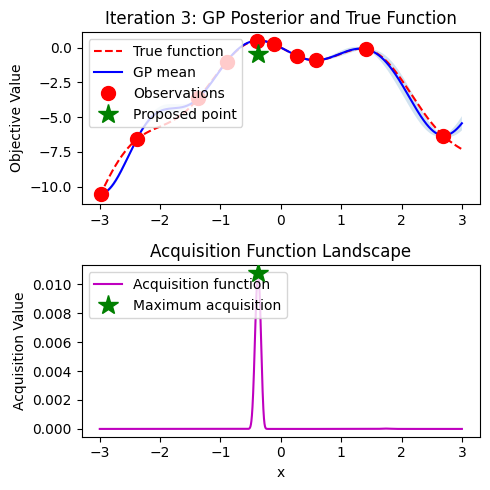

End of Iteration 2: Point _sampled is [-0.37653765] and value is [0.49889003]


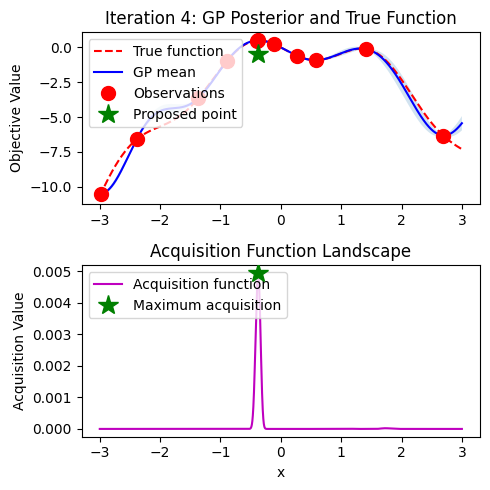

End of Iteration 3: Point _sampled is [-0.37593759] and value is [0.49899144]


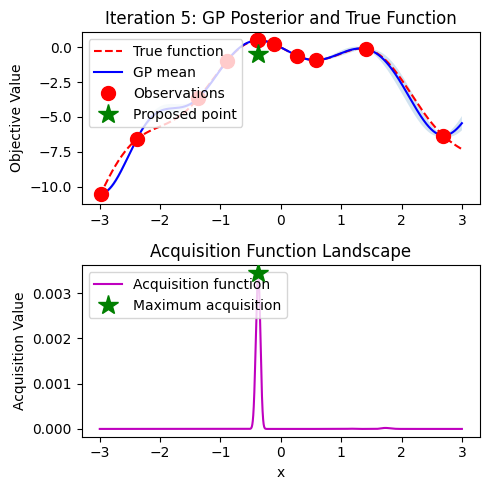

End of Iteration 4: Point _sampled is [-0.37533753] and value is [0.4990892]


In [116]:

X_history, y_history = bayesian_optimization(f, X_train, y_train, [-3,3], n_iter=5, acq_func='ei')
